<a href="https://colab.research.google.com/github/olblinova/python_for_ds_tasks-is-available/blob/main/%22HW_11_2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [4]:
season_map = {
    12: 1, 1: 1, 2: 1,      # Winter
    3: 2, 4: 2, 5: 2,       # Summer
    6: 3, 7: 3, 8: 3, 9: 3, # Monsoon
    10: 4, 11: 4            # Post-Monsoon
}
df['weather_season_india'] = df.index.month.map(season_map)


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [5]:
monthly_avg = df['count'].resample('M').mean()
print(monthly_avg.head())

datetime
2011-01-31     54.645012
2011-02-28     73.641256
2011-03-31     86.849776
2011-04-30    111.026374
2011-05-31    174.809211
Freq: ME, Name: count, dtype: float64


/tmp/ipykernel_1240/4024538812.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['count'].resample('M').mean()


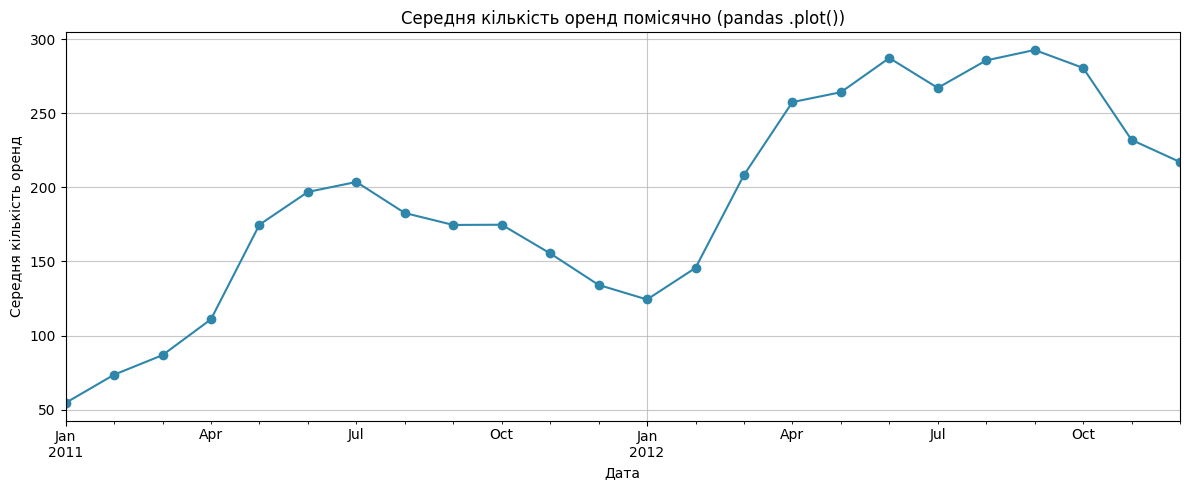

In [6]:
# Використовуючи Pandas (DataFrame.plot())
ax = monthly_avg.plot(
    kind='line',
    marker='o',
    color='#2E86AB',
    figsize=(12, 5),
    title='Середня кількість оренд помісячно (pandas .plot())'
)
ax.set_xlabel('Дата')
ax.set_ylabel('Середня кількість оренд')
ax.grid(True, alpha=0.7)
plt.tight_layout()
plt.savefig('monthly_avg_pandas.png', dpi=150)
plt.show()

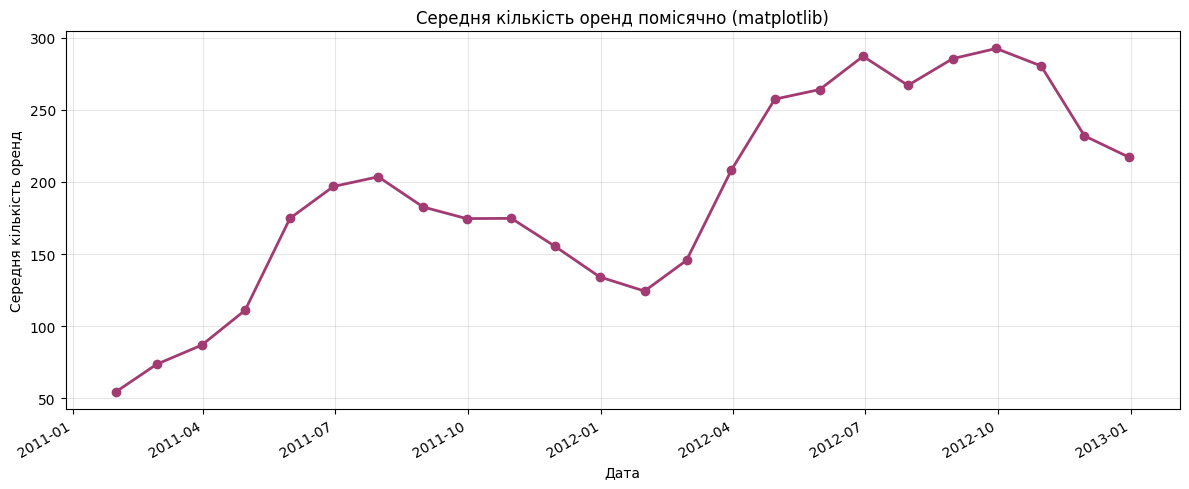

In [7]:
# Використовуючи Matplotlib безпосередньо
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o',
    color='#A23B72',
    linewidth=2
)
ax.set_title('Середня кількість оренд помісячно (matplotlib)')
ax.set_xlabel('Дата')
ax.set_ylabel('Середня кількість оренд')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()  # красивий поворот підписів дат
plt.tight_layout()
plt.savefig('monthly_avg_matplotlib.png', dpi=150)
plt.show()

Обидва графікі показують одну криву,різниця в підписах осі х і, що другий графік не торкається рамок, але має і вертикальну і горизонтальну розмітку. Особисто мені більш подобається з Pandas: простіший код, швидше і зрозуміліше. Matplotlib краще буде, якщо є вимоги до різних налаштувань, що не має Pandas

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [8]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

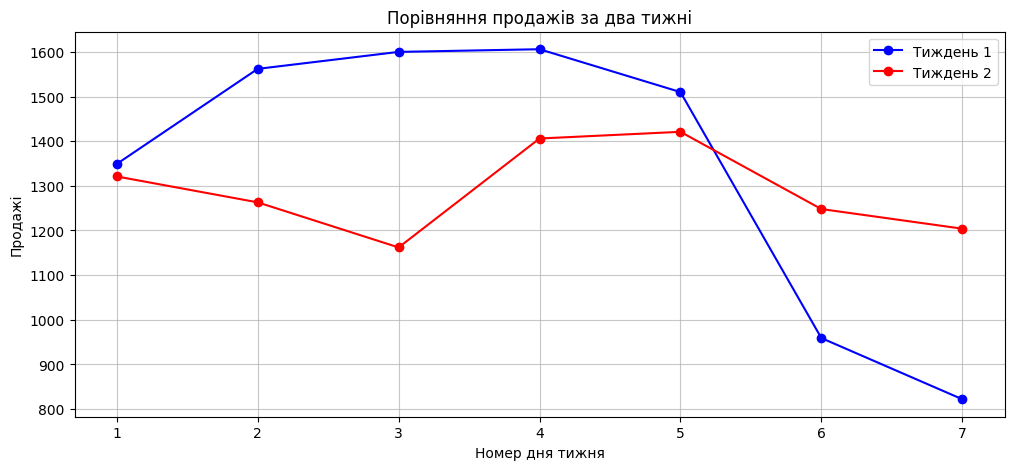

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    days,
    sales_week1,
    color='blue',
    marker='o',
    label='Тиждень 1'
)

plt.plot(
    days,
    sales_week2,
    color='red',
    marker='o',
    label='Тиждень 2'
)

plt.title('Порівняння продажів за два тижні')
plt.xlabel('Номер дня тижня')
plt.ylabel('Продажі')

plt.legend()
plt.grid(True, alpha=0.7)

plt.show()

In [10]:
np.mean(sales_week1)
print('Середнє, тиждень 1:', np.mean(sales_week1))
np.mean(sales_week2)
print('Середнє, тиждень 2:', np.mean(sales_week2))
np.std(sales_week1)
print('Стандартне відхилення, тиждень 1:', np.std(sales_week1))
np.std(sales_week2)
print('Стандартне відхилення, тиждень 2:', np.std(sales_week2))

Середнє, тиждень 1: 1344.0
Середнє, тиждень 2: 1289.2857142857142
Стандартне відхилення, тиждень 1: 299.99857142517004
Стандартне відхилення, тиждень 2: 90.9060964256355


Судячи з графіку, на другому тижні продажі були стабільніші, це підтверджує стандартне відхилення, яке менше десь на 3,2 на другому тижні відносно першого, тобто трималися набагато ближче до свого середнього значення - були передбачуванішими

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [11]:
# Середня температура помісячно
monthly_temp = df['temp'].resample('M').mean()
print(monthly_temp.head())

datetime
2011-01-31     8.633782
2011-02-28    11.331076
2011-03-31    14.063184
2011-04-30    17.776879
2011-05-31    21.528596
Freq: ME, Name: temp, dtype: float64


/tmp/ipykernel_1240/1380901706.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df['temp'].resample('M').mean()


In [12]:
# Середня годинна кількість оренд за кварталами
quarter_avg_rentals = df.groupby('season')['count'].mean()
quarter_labels = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}

In [13]:
# Bологість за всіма погодинними вимірами
df['humidity']
# Температура vs кількість оренд
df['temp'], df['count']

(datetime
 2011-01-01 00:00:00     9.84
 2011-01-01 01:00:00     9.02
 2011-01-01 02:00:00     9.02
 2011-01-01 03:00:00     9.84
 2011-01-01 04:00:00     9.84
                        ...  
 2012-12-19 19:00:00    15.58
 2012-12-19 20:00:00    14.76
 2012-12-19 21:00:00    13.94
 2012-12-19 22:00:00    13.94
 2012-12-19 23:00:00    13.12
 Name: temp, Length: 10886, dtype: float64,
 datetime
 2011-01-01 00:00:00     16
 2011-01-01 01:00:00     40
 2011-01-01 02:00:00     32
 2011-01-01 03:00:00     13
 2011-01-01 04:00:00      1
                       ... 
 2012-12-19 19:00:00    336
 2012-12-19 20:00:00    241
 2012-12-19 21:00:00    168
 2012-12-19 22:00:00    129
 2012-12-19 23:00:00     88
 Name: count, Length: 10886, dtype: int64)

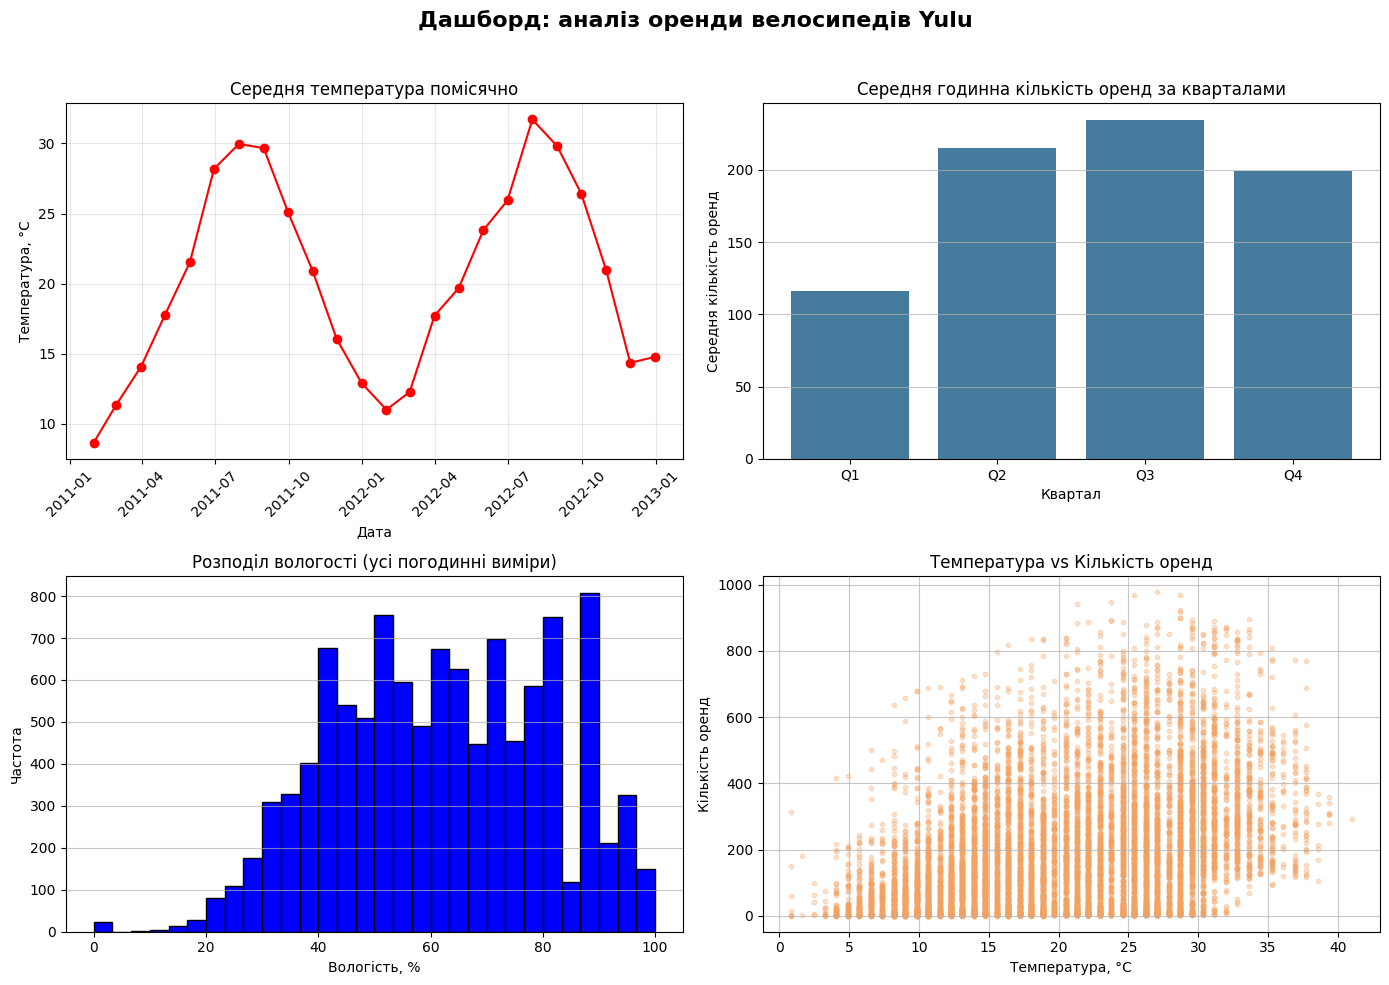

In [21]:
plt.figure(figsize=(14, 10))
plt.suptitle('Дашборд: аналіз оренди велосипедів Yulu', fontsize=16, fontweight='bold')

plt.subplot(2, 2, 1)
plt.plot(monthly_temp.index, monthly_temp.values, marker='o', color='r')
plt.title('Середня температура помісячно')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
plt.bar(
    [quarter_labels[q] for q in quarter_avg_rentals.index],
    quarter_avg_rentals.values,
    color='#457B9D'
)
plt.title('Середня годинна кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')
plt.grid(True, axis='y', alpha=0.7)

plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=30, color='b', edgecolor='black')
plt.title('Розподіл вологості (усі погодинні виміри)')
plt.xlabel('Вологість, %')
plt.ylabel('Частота')
plt.grid(True, axis='y', alpha=0.7)

plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha=0.3, s=10, color='#F4A261')
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура, °C')
plt.ylabel('Кількість оренд')
plt.grid(True, alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('dashboard_2x2.png', dpi=300)
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

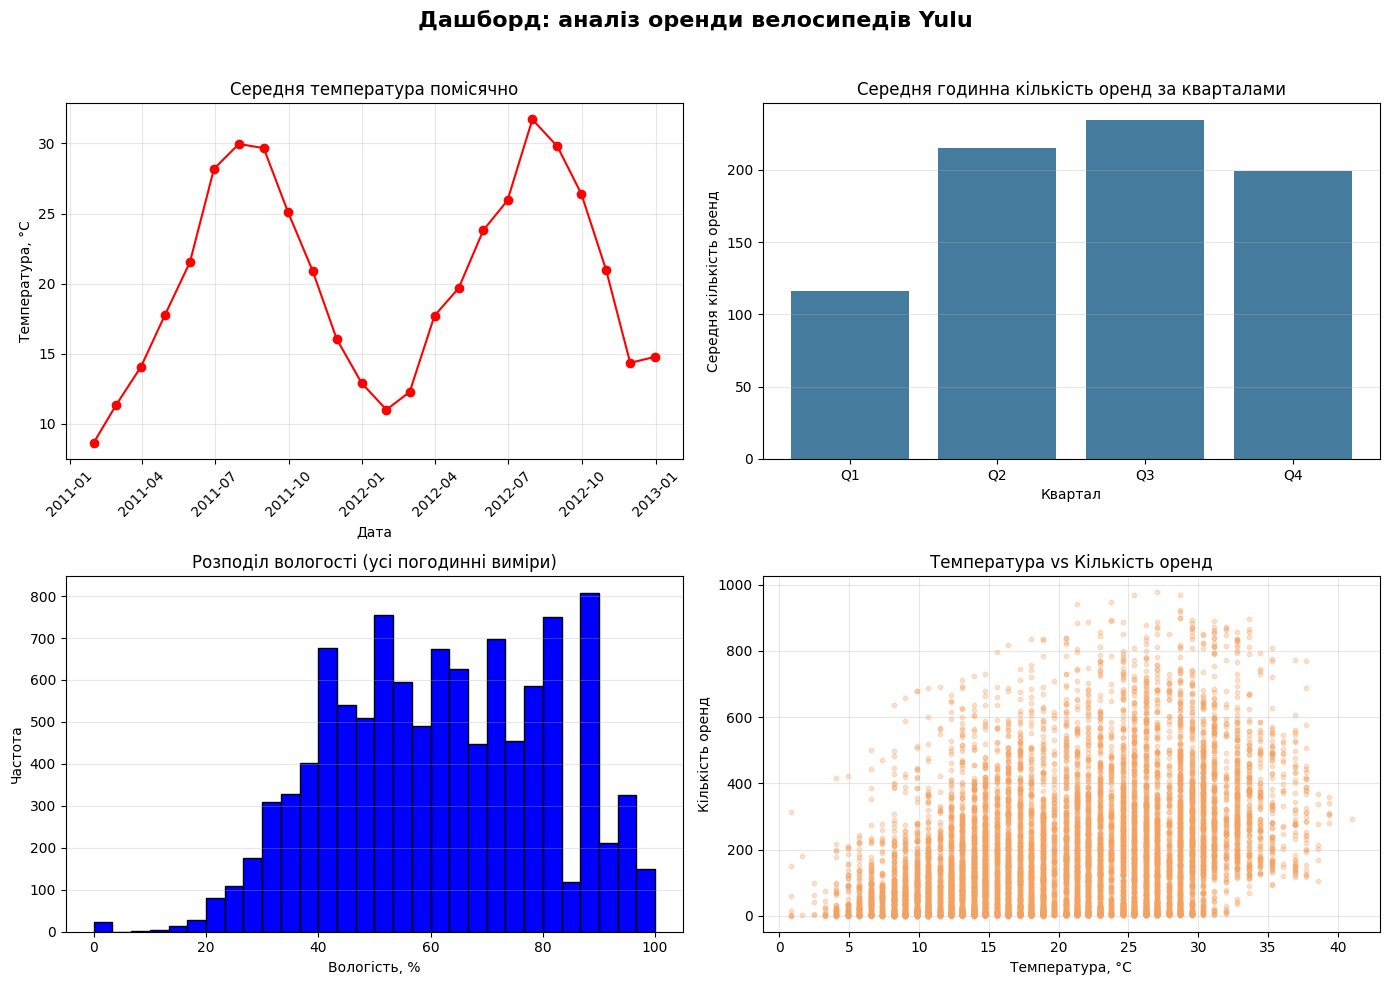

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Дашборд: аналіз оренди велосипедів Yulu', fontsize=16, fontweight='bold')

# лінійний графік середньої температури помісячно
axs[0, 0].plot(monthly_temp.index, monthly_temp.values, marker='o', color='r')
axs[0, 0].set_title('Середня температура помісячно')
axs[0, 0].set_xlabel('Дата')
axs[0, 0].set_ylabel('Температура, °C')
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].tick_params(axis='x', rotation=45)

# стовпчикова діаграма середньої годинної кількості оренд за кварталами
axs[0, 1].bar(
    [quarter_labels[q] for q in quarter_avg_rentals.index],
    quarter_avg_rentals.values,
    color='#457B9D'
)
axs[0, 1].set_title('Середня годинна кількість оренд за кварталами')
axs[0, 1].set_xlabel('Квартал')
axs[0, 1].set_ylabel('Середня кількість оренд')
axs[0, 1].grid(True, axis='y', alpha=0.3)

# гістограма вологості за всіма погодинними вимірами
axs[1, 0].hist(df['humidity'], bins=30, color='blue', edgecolor='black')
axs[1, 0].set_title('Розподіл вологості (усі погодинні виміри)')
axs[1, 0].set_xlabel('Вологість, %')
axs[1, 0].set_ylabel('Частота')
axs[1, 0].grid(True, axis='y', alpha=0.3)

# scatter plot температури vs кількості оренд
axs[1, 1].scatter(df['temp'], df['count'], alpha=0.3, s=10, color='#F4A261')
axs[1, 1].set_title('Температура vs Кількість оренд')
axs[1, 1].set_xlabel('Температура, °C')
axs[1, 1].set_ylabel('Кількість оренд')
axs[1, 1].grid(True, alpha=0.3)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('dashboard_2x2_oop.png', dpi=150)
plt.show()

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [26]:
import matplotlib.ticker as mticker

In [27]:
# Агрегація помісячно: середнє, максимум, мінімум
monthly_stats = df['count'].resample('M').agg(['mean', 'max', 'min'])
monthly_stats.columns = ['avg', 'max', 'min']

overall_avg = df['count'].mean()

# Місяці з найвищим і найнижчим середнім
best_month = monthly_stats['avg'].idxmax()
worst_month = monthly_stats['avg'].idxmin()
best_value = monthly_stats.loc[best_month, 'avg']
worst_value = monthly_stats.loc[worst_month, 'avg']

/tmp/ipykernel_1240/3197481991.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_stats = df['count'].resample('M').agg(['mean', 'max', 'min'])


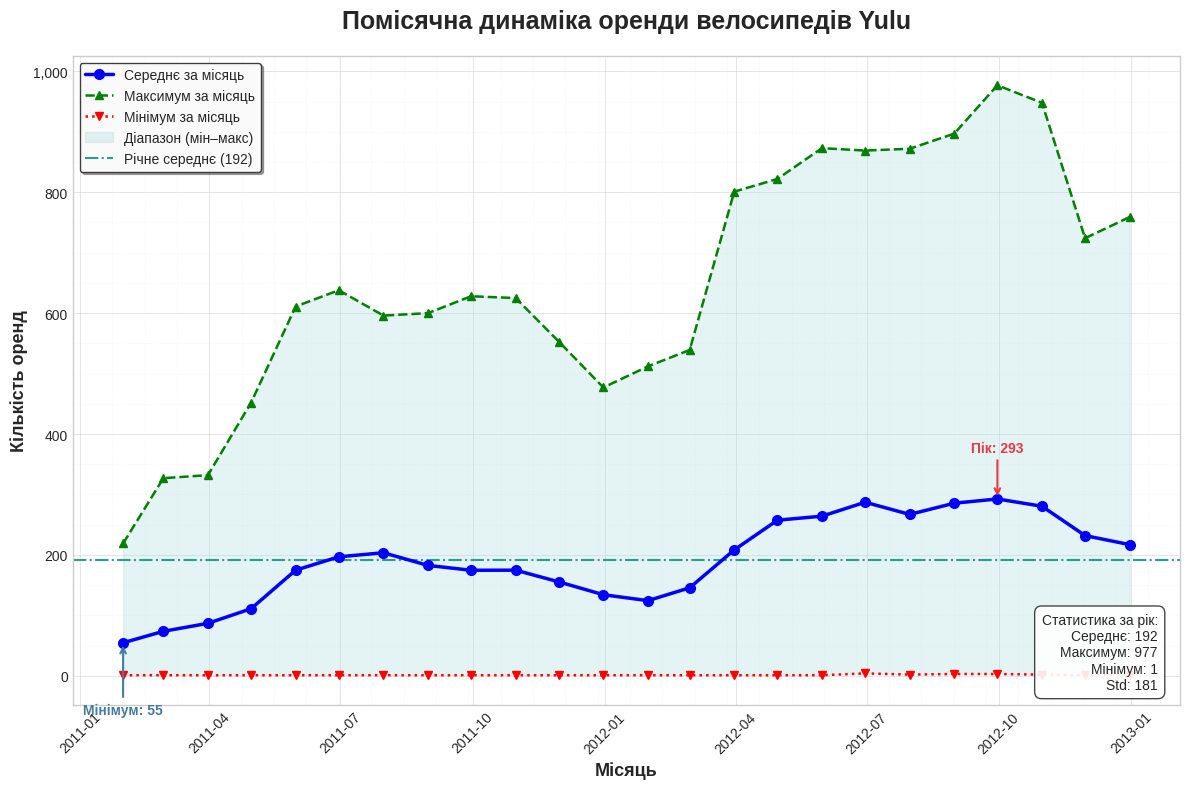

In [31]:
plt.style.use('seaborn-v0_8-whitegrid')  # чиста, "звітна" базова стилістика

fig, ax = plt.subplots(figsize=(12, 8))

x = monthly_stats.index

# 3 лінії: середнє, максимум, мінімум (різні стилі + маркери)
ax.plot(
    x, monthly_stats['avg'],
    linestyle='-', marker='o', linewidth=2.5, markersize=7,
    color='blue', label='Середнє за місяць', zorder=3
)
ax.plot(
    x, monthly_stats['max'],
    linestyle='--', marker='^', linewidth=1.8, markersize=6,
    color='green', label='Максимум за місяць', zorder=3
)
ax.plot(
    x, monthly_stats['min'],
    linestyle=':', marker='v', linewidth=1.8, markersize=6,
    color='red', label='Мінімум за місяць', zorder=3
)

# Заливка області між мінімумом та максимумом
ax.fill_between(
    x, monthly_stats['min'], monthly_stats['max'],
    color='#A8DADC', alpha=0.3, label='Діапазон (мін–макс)', zorder=1
)

# Горизонтальна лінія середнього за весь рік
ax.axhline(
    overall_avg, color='#2A9D8F', linestyle='-.', linewidth=1.5,
    label=f'Річне середнє ({overall_avg:.0f})', zorder=2
)

# Анотації: найвище та найнижче середнє значення
ax.annotate(
    f'Пік: {best_value:.0f}',
    xy=(best_month, best_value),
    xytext=(best_month, best_value + (monthly_stats['max'].max() * 0.08)),
    ha='center', fontsize=10, fontweight='bold', color='#E63946',
    arrowprops=dict(arrowstyle='->', color='#E63946', lw=1.5)
)
ax.annotate(
    f'Мінімум: {worst_value:.0f}',
    xy=(worst_month, worst_value),
    xytext=(worst_month, worst_value - (monthly_stats['max'].max() * 0.12)),
    ha='center', fontsize=10, fontweight='bold', color='#457B9D',
    arrowprops=dict(arrowstyle='->', color='#457B9D', lw=1.5)
)

# Двошарова сітка: основна та допоміжна
ax.minorticks_on()
ax.grid(which='major', linestyle='-', linewidth=0.7, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.3)

# Заголовок та підписи осей (жирний шрифт)
ax.set_title(
    'Помісячна динаміка оренди велосипедів Yulu',
    fontsize=18, fontweight='bold', pad=20
)
ax.set_xlabel('Місяць', fontsize=13, fontweight='bold')
ax.set_ylabel('Кількість оренд', fontsize=13, fontweight='bold')

ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

# Легенда з тінню
legend = ax.legend(
    loc='upper left', fontsize=10, frameon=True,
    shadow=True, fancybox=True, framealpha=0.95
)
legend.get_frame().set_edgecolor('#333333')

# Текстовий блок зі статистикою в кутку графіка
stats_text = (
    f"Статистика за рік:\n"
    f"Середнє: {overall_avg:.0f}\n"
    f"Максимум: {monthly_stats['max'].max():.0f}\n"
    f"Мінімум: {monthly_stats['min'].min():.0f}\n"
    f"Std: {df['count'].std():.0f}"
)
ax.text(
    0.98, 0.02, stats_text,
    transform=ax.transAxes,
    fontsize=10, va='bottom', ha='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
              edgecolor='#333333', alpha=0.9)
)

fig.tight_layout()
fig.savefig('monthly_rental_dynamics_pro.png', dpi=200, bbox_inches='tight');